In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
import librosa.display
import os
import warnings
warnings.filterwarnings('ignore')

print("Imports OK")

Imports OK


In [6]:
df = pd.read_csv('../all_data_updated.csv')

print("Shape:", df.shape)
print("\nDistribution des classes (queen status):")
print(df['queen status'].value_counts())

# Mapping lisible
class_names = {
    0: 'Queen Not Present',
    1: 'Queen Present - Newly Accepted',
    2: 'Queen Present - Rejected',
    3: 'Queen Present - Original'
}
df['class_name'] = df['queen status'].map(class_names)
print("\nDistribution lisible:")
print(df['class_name'].value_counts())

Shape: (1275, 23)

Distribution des classes (queen status):
queen status
3    679
2    259
0    179
1    158
Name: count, dtype: int64

Distribution lisible:
class_name
Queen Present - Original          679
Queen Present - Rejected          259
Queen Not Present                 179
Queen Present - Newly Accepted    158
Name: count, dtype: int64


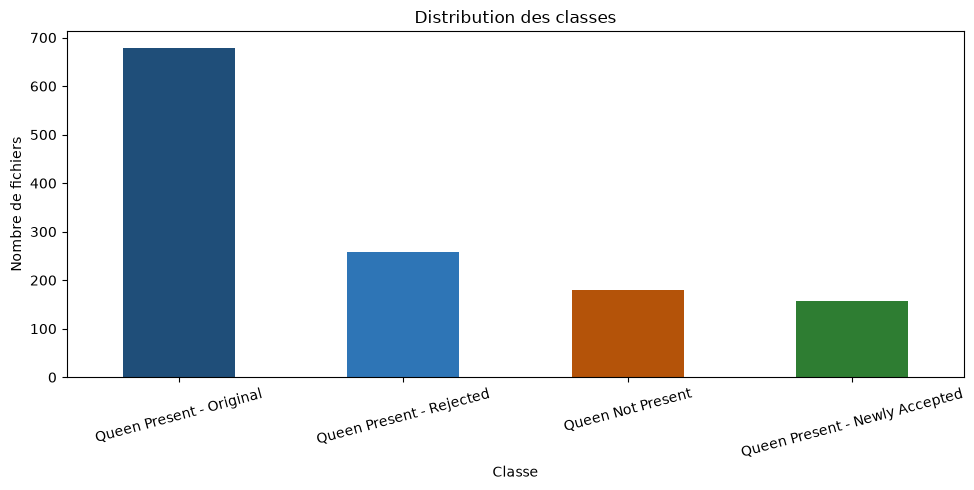

In [7]:
plt.figure(figsize=(10, 5))
df['class_name'].value_counts().plot(kind='bar', color=['#1F4E79','#2E75B6','#B45309','#2E7D32'])
plt.title('Distribution des classes')
plt.xlabel('Classe')
plt.ylabel('Nombre de fichiers')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

In [8]:
# Construire le chemin vers un fichier audio
AUDIO_DIR = '../data/sound_files/'

# Lister les premiers fichiers pour voir le format exact
files = os.listdir(AUDIO_DIR)
print("Premiers fichiers dans sound_files/:")
for f in files[:10]:
    print(f)

Premiers fichiers dans sound_files/:
2022-06-05--17-41-01_2__segment0.wav
2022-06-05--17-41-01_2__segment1.wav
2022-06-05--17-41-01_2__segment2.wav
2022-06-05--17-41-01_2__segment3.wav
2022-06-05--17-41-01_2__segment4.wav
2022-06-05--17-41-01_2__segment5.wav
2022-06-05--18-40-08_2__segment0.wav
2022-06-05--18-40-08_2__segment1.wav
2022-06-05--18-40-08_2__segment2.wav
2022-06-05--18-40-08_2__segment3.wav


In [9]:
# Le CSV a des noms comme : 2022-06-05--17-41-01_2.raw
# Les fichiers audio sont  : 2022-06-05--17-41-01_2__segment0.wav

# On extrait le "stem" du nom de fichier (sans extension)
df['file_stem'] = df['file name'].str.replace('.raw', '', regex=False)

# On liste tous les fichiers audio et on extrait leur stem (sans __segmentX.wav)
all_audio_files = os.listdir(AUDIO_DIR)

# Construire un dictionnaire stem -> liste de segments
from collections import defaultdict
stem_to_segments = defaultdict(list)
for f in all_audio_files:
    if f.endswith('.wav'):
        stem = f.split('__segment')[0]
        stem_to_segments[stem].append(f)

print("Exemple de correspondance :")
example_stem = df['file_stem'].iloc[0]
print(f"  CSV stem     : {example_stem}")
print(f"  Segments     : {stem_to_segments.get(example_stem, 'AUCUN')}")

print(f"\nNombre de stems dans le CSV       : {df['file_stem'].nunique()}")
print(f"Nombre de stems trouvés dans audio : {len(stem_to_segments)}")

Exemple de correspondance :
  CSV stem     : 2022-06-08--14-52-28_1
  Segments     : ['2022-06-08--14-52-28_1__segment0.wav', '2022-06-08--14-52-28_1__segment1.wav', '2022-06-08--14-52-28_1__segment2.wav', '2022-06-08--14-52-28_1__segment3.wav', '2022-06-08--14-52-28_1__segment4.wav', '2022-06-08--14-52-28_1__segment5.wav']

Nombre de stems dans le CSV       : 1275
Nombre de stems trouvés dans audio : 1222


In [11]:
# Pour chaque ligne du CSV, on récupère tous ses segments
rows = []
for _, row in df.iterrows():
    stem = row['file_stem']
    segments = stem_to_segments.get(stem, [])
    for seg in sorted(segments):
        rows.append({
            'file_path': os.path.join(AUDIO_DIR, seg),
            'label': int(row['queen status']),
            'class_name': row['class_name'],
            'stem': stem
        })

df_segments = pd.DataFrame(rows)
print("Shape du dataframe segments:", df_segments.shape)
print("\nDistribution des classes (segments):")
print(df_segments['class_name'].value_counts())

Shape du dataframe segments: (7100, 4)

Distribution des classes (segments):
class_name
Queen Present - Original          3563
Queen Present - Rejected          1553
Queen Not Present                 1038
Queen Present - Newly Accepted     946
Name: count, dtype: int64


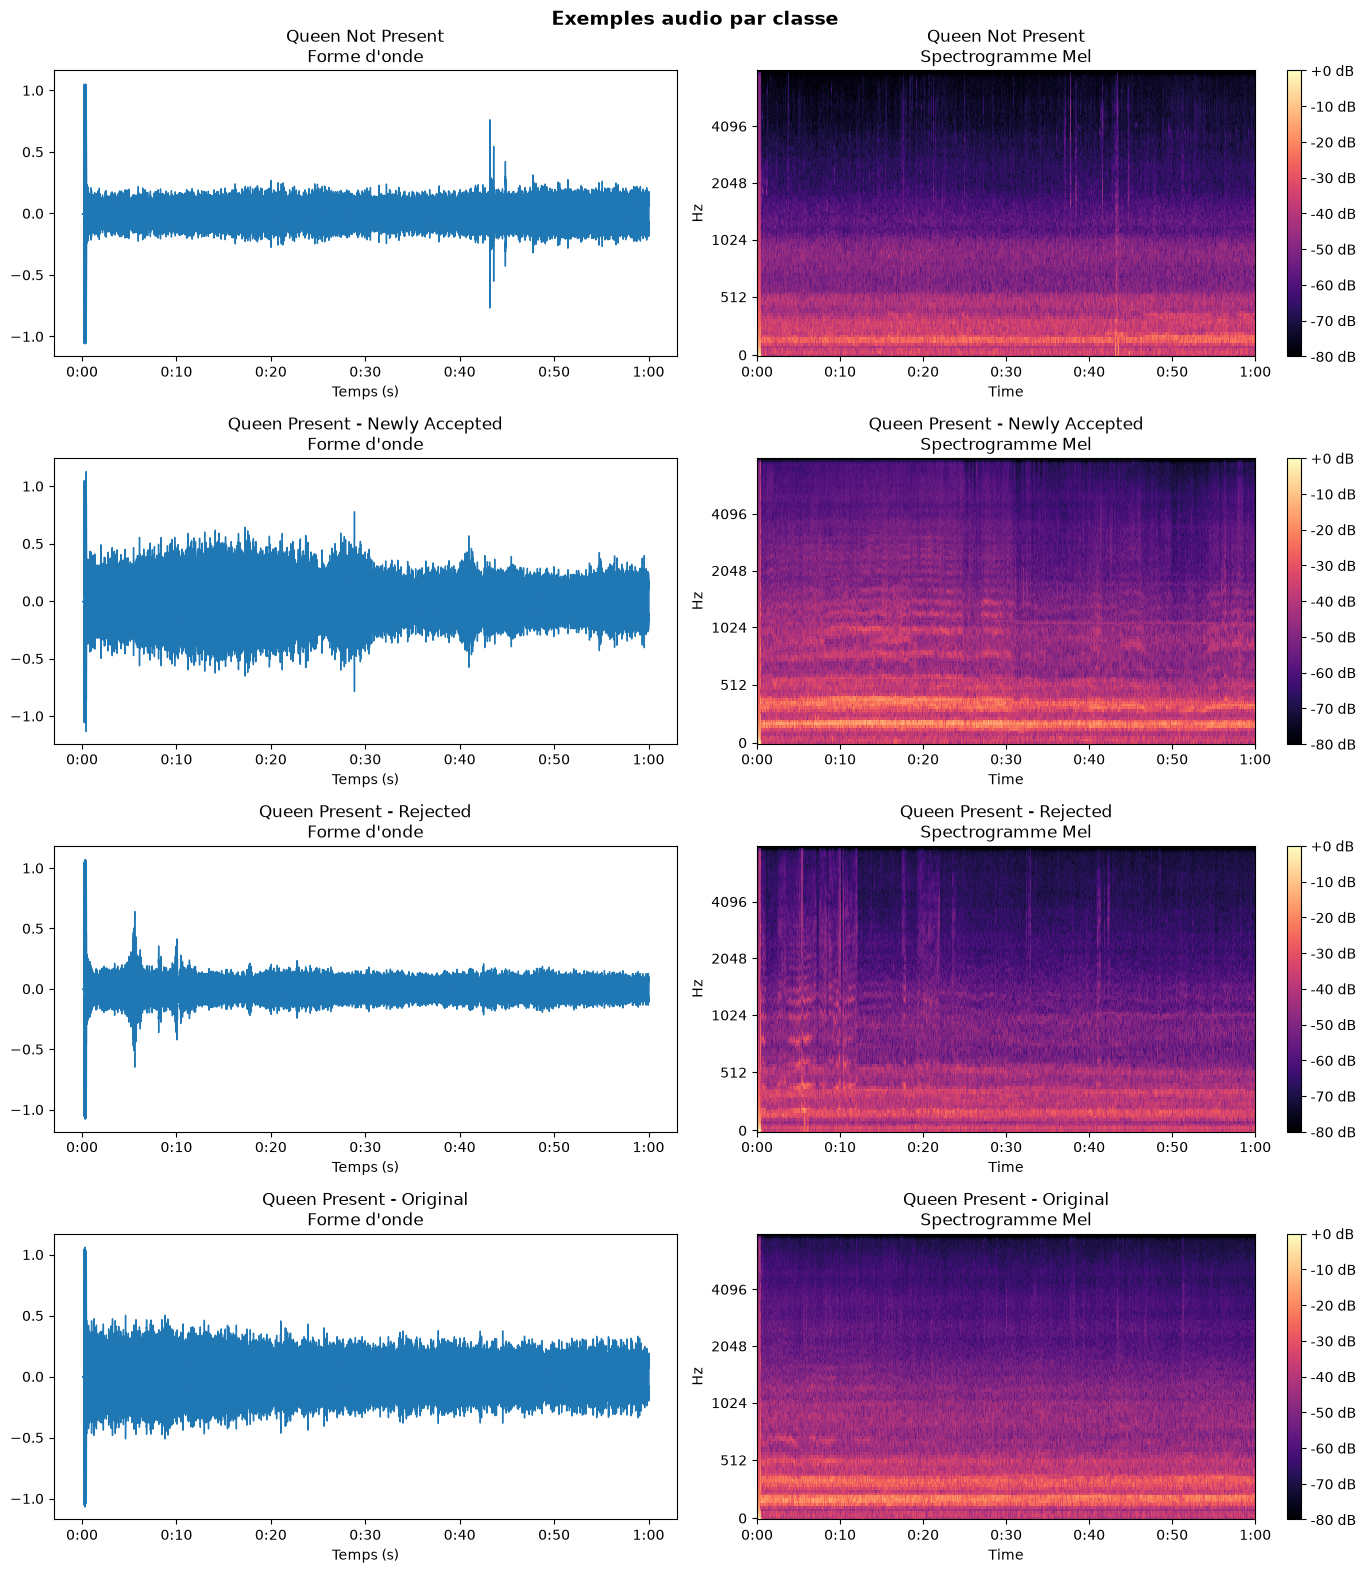

Visualisation sauvegardée.


In [12]:
import librosa.display

fig, axes = plt.subplots(4, 2, figsize=(14, 16))
fig.suptitle('Exemples audio par classe', fontsize=14, fontweight='bold')

for idx, (label, class_name) in enumerate(class_names.items()):
    # Prendre un exemple de cette classe
    sample = df_segments[df_segments['label'] == label].iloc[0]
    audio, sr = librosa.load(sample['file_path'], sr=16000)

    # Forme d'onde
    ax_wave = axes[idx][0]
    librosa.display.waveshow(audio, sr=sr, ax=ax_wave)
    ax_wave.set_title(f'{class_name}\nForme d\'onde')
    ax_wave.set_xlabel('Temps (s)')

    # Spectrogramme Mel
    ax_mel = axes[idx][1]
    mel = librosa.feature.melspectrogram(y=audio, sr=sr, n_mels=128, fmax=8000)
    mel_db = librosa.power_to_db(mel, ref=np.max)
    librosa.display.specshow(mel_db, sr=sr, x_axis='time',
                             y_axis='mel', ax=ax_mel, fmax=8000)
    ax_mel.set_title(f'{class_name}\nSpectrogramme Mel')
    plt.colorbar(ax_mel.collections[0], ax=ax_mel, format='%+2.0f dB')

plt.tight_layout()
plt.savefig('../notebooks/classes_visualization.png', dpi=100)
plt.show()
print("Visualisation sauvegardée.")

In [13]:
# Vérifier sur quelques exemples
print("Vérification durée et sample rate sur 5 fichiers :")
for _, row in df_segments.sample(5, random_state=42).iterrows():
    audio, sr = librosa.load(row['file_path'], sr=None)
    duration = len(audio) / sr
    print(f"  Fichier : {os.path.basename(row['file_path'])}")
    print(f"  SR      : {sr} Hz | Durée : {duration:.1f}s | Classe : {row['class_name']}")
    print()

Vérification durée et sample rate sur 5 fichiers :
  Fichier : 2022-06-27--09-22-28_2__segment3.wav
  SR      : 22050 Hz | Durée : 60.0s | Classe : Queen Present - Newly Accepted

  Fichier : 2022-07-06--13-14-32_1__segment3.wav
  SR      : 22050 Hz | Durée : 60.0s | Classe : Queen Present - Original

  Fichier : 2022-06-15--23-19-48_2__segment4.wav
  SR      : 22050 Hz | Durée : 60.0s | Classe : Queen Not Present

  Fichier : 2022-07-05--00-57-29_2__segment1.wav
  SR      : 22050 Hz | Durée : 60.0s | Classe : Queen Present - Original

  Fichier : 2022-07-10--03-42-26_1__segment3.wav
  SR      : 22050 Hz | Durée : 60.0s | Classe : Queen Present - Original



In [14]:
df_segments.to_csv('../all_segments.csv', index=False)
print(f"Dataframe sauvegardé : {len(df_segments)} segments")
print("Fichier : all_segments.csv")

Dataframe sauvegardé : 7100 segments
Fichier : all_segments.csv


In [ ]:
import sys
sys.path.append('../src')

# Vider le cache des imports
for mod in list(sys.modules.keys()):
    if 'dataset' in mod or 'model' in mod or 'train' in mod:
        del sys.modules[mod]

from dataset import build_windows_dataframe, prepare_splits, BeeDataset, extract_mfcc

# Étape 1 : construire le dataframe des fenêtres
df_windows = build_windows_dataframe('../all_segments.csv')

# Étape 2 : tester le split
df_train, df_val, df_test = prepare_splits(df_windows)

# Étape 3 : tester l'extraction MFCC sur une fenêtre
import librosa
import numpy as np

sample_row = df_train.iloc[0]
audio, _   = librosa.load(sample_row['file_path'], sr=16000)
windows    = []
window_samples = 16000 * 5
hop_samples    = 16000 * 2
start = 0
while start + window_samples <= len(audio):
    windows.append(audio[start:start + window_samples])
    start += hop_samples

window = windows[int(sample_row['window_idx'])]
mfcc   = extract_mfcc(window)
print(f"\nForme du MFCC (fenêtre 5s) : {mfcc.shape}")
print(f"Min : {mfcc.min():.3f} | Max : {mfcc.max():.3f}")

# Étape 4 : tester le Dataset PyTorch
from model import BeeModel
import torch

dataset        = BeeDataset(df_train)
tensor, label  = dataset[0]
print(f"\nForme du tensor : {tensor.shape}")
print(f"Label           : {label}")

# Étape 5 : tester le modèle avec cette nouvelle taille
model      = BeeModel(num_classes=4)
dummy      = torch.zeros(4, 1, 40, 313)
output     = model(dummy)
print(f"\nEntrée modèle : {dummy.shape}")
print(f"Sortie modèle : {output.shape}")
print(f"Paramètres    : {sum(p.numel() for p in model.parameters()):,}")

Découpage de 7100 fichiers en fenêtres de 5s...
  0/7100...


In [15]:
# Recharger les modules modifiés
import importlib
import sys 

# Vider le cache des imports
for mod in list(sys.modules.keys()):
    if 'dataset' in mod or 'model' in mod or 'train' in mod:
        del sys.modules[mod]

from train import train
model, test_loader, class_weights = train()

Device : cuda

Chargement des données...
Cache trouvé — chargement de ../all_segments_windows.csv
Total fenêtres : 85200
class_name
Queen Present - Original          42756
Queen Present - Rejected          18636
Queen Not Present                 12456
Queen Present - Newly Accepted    11352
Name: count, dtype: int64
Train : 59640 fenêtres
Val   : 12780 fenêtres
Test  : 12780 fenêtres

Poids des classes :
  Queen Not Present: 0.2937
  Queen Present - Newly Accepted: 0.3077
  Queen Present - Rejected: 0.2401
  Queen Present - Original: 0.1585

Modèle chargé — 961,540 paramètres

Début entraînement — 20 epochs


Epoch 1/20
----------------------------------------
  Batch 20/1864 | Loss: 1.3295
  Batch 40/1864 | Loss: 1.4543
  Batch 60/1864 | Loss: 1.4050
  Batch 80/1864 | Loss: 1.3722
  Batch 100/1864 | Loss: 1.3374
  Batch 120/1864 | Loss: 1.3546
  Batch 140/1864 | Loss: 1.4007
  Batch 160/1864 | Loss: 1.2115
  Batch 180/1864 | Loss: 1.3669
  Batch 200/1864 | Loss: 1.3056
  Batch 220/186

In [16]:
import torch
print(f"CUDA disponible : {torch.cuda.is_available()}")
print(f"GPU détecté     : {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'Aucun'}")
print(f"Version CUDA    : {torch.version.cuda}")

CUDA disponible : True
GPU détecté     : NVIDIA GeForce GTX 1650
Version CUDA    : 12.4


Modèle chargé — epoch 20 | Val Acc : 0.9154
Cache trouvé — chargement de ../all_segments_windows.csv
Total fenêtres : 85200
class_name
Queen Present - Original          42756
Queen Present - Rejected          18636
Queen Not Present                 12456
Queen Present - Newly Accepted    11352
Name: count, dtype: int64
Train : 59640 fenêtres
Val   : 12780 fenêtres
Test  : 12780 fenêtres

Poids des classes :
  Queen Not Present: 0.2937
  Queen Present - Newly Accepted: 0.3077
  Queen Present - Rejected: 0.2401
  Queen Present - Original: 0.1585

RAPPORT DE CLASSIFICATION
                   precision    recall  f1-score   support

Queen Not Present      0.881     0.943     0.911      1868
   Newly Accepted      0.827     0.873     0.849      1703
         Rejected      0.898     0.853     0.875      2795
         Original      0.958     0.945     0.952      6414

         accuracy                          0.915     12780
        macro avg      0.891     0.904     0.897     12780
     wei

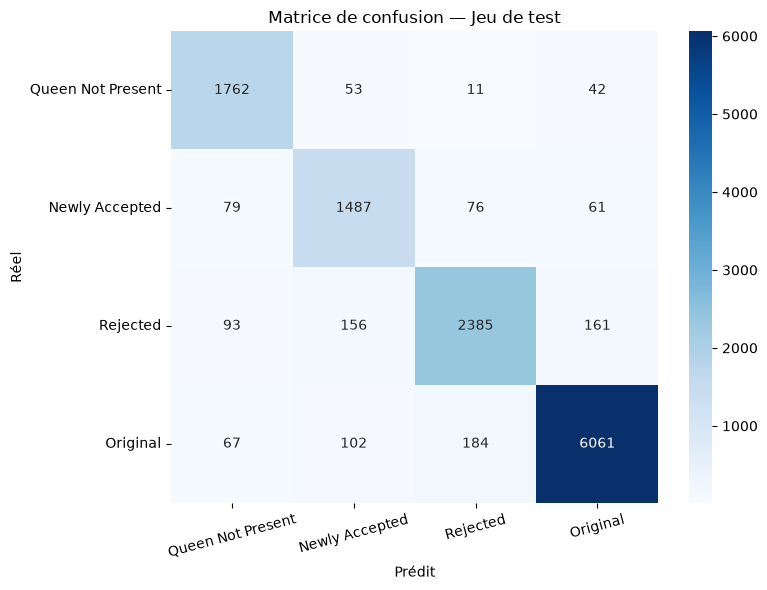

Matrice de confusion sauvegardée.

Weighted F1 : 0.9153
Macro F1    : 0.8967
AUC-ROC     : 0.9893


In [17]:
import sys
sys.path.append('../src')
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (classification_report, confusion_matrix,
                              f1_score, roc_auc_score)
from sklearn.preprocessing import label_binarize

# Vider le cache
for mod in list(sys.modules.keys()):
    if 'dataset' in mod or 'model' in mod or 'train' in mod:
        del sys.modules[mod]

from model import BeeModel
from dataset import get_dataloaders

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
CLASS_NAMES = ['Queen Not Present', 'Newly Accepted', 'Rejected', 'Original']

# ── Charger le meilleur modèle ────────────────────────────────────────────────
model      = BeeModel(num_classes=4).to(DEVICE)
checkpoint = torch.load('../models/best_model.pt', map_location=DEVICE)
model.load_state_dict(checkpoint['model_state'])
model.eval()
print(f"Modèle chargé — epoch {checkpoint['epoch']} | Val Acc : {checkpoint['val_acc']:.4f}")

# ── Charger le test loader ────────────────────────────────────────────────────
_, _, test_loader, _ = get_dataloaders('../all_segments.csv')

# ── Prédictions sur le jeu de test ───────────────────────────────────────────
all_preds  = []
all_labels = []
all_probs  = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(DEVICE)
        outputs = model(inputs)
        probs   = torch.softmax(outputs, dim=1)
        preds   = outputs.argmax(dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())
        all_probs.extend(probs.cpu().numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs  = np.array(all_probs)

# ── 1. Rapport de classification ──────────────────────────────────────────────
print("\n" + "="*60)
print("RAPPORT DE CLASSIFICATION")
print("="*60)
print(classification_report(all_labels, all_preds,
                             target_names=CLASS_NAMES, digits=3))

# ── 2. Matrice de confusion ───────────────────────────────────────────────────
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title('Matrice de confusion — Jeu de test')
plt.ylabel('Réel')
plt.xlabel('Prédit')
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('../models/confusion_matrix.png', dpi=100)
plt.show()
print("Matrice de confusion sauvegardée.")

# ── 3. F1 Score global ────────────────────────────────────────────────────────
weighted_f1 = f1_score(all_labels, all_preds, average='weighted')
macro_f1    = f1_score(all_labels, all_preds, average='macro')
print(f"\nWeighted F1 : {weighted_f1:.4f}")
print(f"Macro F1    : {macro_f1:.4f}")

# ── 4. AUC-ROC ────────────────────────────────────────────────────────────────
labels_bin = label_binarize(all_labels, classes=[0,1,2,3])
auc_score  = roc_auc_score(labels_bin, all_probs,
                            multi_class='ovr', average='weighted')
print(f"AUC-ROC     : {auc_score:.4f}")

In [21]:
import requests
import os

CLASS_NAMES = {
    0: 'Queen Not Present',
    1: 'Queen Present - Newly Accepted',
    2: 'Queen Present - Rejected',
    3: 'Queen Present - Original'
}

# Tester /health
resp = requests.get('http://localhost:5000/health')
print("Health check :", resp.json())

# Prendre un fichier audio directement depuis le dossier
AUDIO_DIR   = '../data/sound_files/'
sample_file = os.path.join(AUDIO_DIR, os.listdir(AUDIO_DIR)[0])
print(f"\nFichier test : {os.path.basename(sample_file)}")

with open(sample_file, 'rb') as f:
    resp = requests.post('http://localhost:5000/predict',
                         files={'file': f})

result = resp.json()
print(f"\nPrédiction   : {result['prediction']}")
print(f"Confiance    : {result['confidence']:.1%}")
print(f"Conseil      : {result['recommendation']}")
print(f"Fenêtres     : {result['windows_count']}")
print(f"\nProbabilités :")
for cls, prob in result['probabilities'].items():
    bar = '█' * int(prob * 20)
    print(f"  {cls[:30]:<30} {prob:.3f}  {bar}")

Health check : {'device': 'cuda', 'model': 'BeeModel v1.0', 'status': 'ok', 'val_acc': 0.9154}

Fichier test : 2022-06-05--17-41-01_2__segment0.wav

Prédiction   : Queen Not Present
Confiance    : 99.9%
Conseil      : URGENT : La reine est absente. Inspectez la ruche immédiatement.
Fenêtres     : 12

Probabilités :
  Queen Not Present              0.999  ███████████████████
  Queen Present - Newly Accepted 0.001  
  Queen Present - Original       0.000  
  Queen Present - Rejected       0.000  


In [22]:
import sys
sys.path.append('../src')

for mod in list(sys.modules.keys()):
    if 'predict' in mod or 'model' in mod:
        del sys.modules[mod]

from predict import predict
import os

# Tester sur un fichier audio réel
sample_file = os.path.join('../data/sound_files/', 
                            os.listdir('../data/sound_files/')[0])
result = predict(sample_file)


Fichier      : 2022-06-05--17-41-01_2__segment0.wav
Prédiction   : Queen Not Present
Confiance    : 99.9%
Conseil      : URGENT : La reine est absente. Inspectez la ruche immédiatement.
Fenêtres     : 12

Probabilités :
  Queen Not Present                   0.999  ███████████████████
  Queen Present - Newly Accepted      0.001  
  Queen Present - Rejected            0.000  
  Queen Present - Original            0.000  
